# DATA 620 - Project 1  
## Centrality Measures in the Spotify Artist Collaboration Network

**Course:** DATA 620 - Web Analytics  
**Project:** Project 1 - Centrality Measures Across Categorical Groups  

**Group Members:**  
- Crystal Quezada  
- Nana Kwasi Danquah  
- Muhammad Suffyan Khan  

**Dataset:** Spotify Artist Feature Collaboration Network  

# Objective

In this project, we analyze a Spotify artist collaboration network. In this network, each node represents an artist, and each edge represents a collaboration or feature relationship between two artists. The categorical variable used for comparison is each artist's music genre group.

The main research question is:

**Do artists from different music genre groups differ in their network centrality within the Spotify collaboration network?**

We focus on two centrality measures:
- **Degree centrality**, which measures how many direct collaboration connections an artist has.
- **Eigenvector centrality**, which measures whether an artist is connected to other highly connected artists.

# Dataset Description

The dataset contains two main files:

1. **nodes.csv** - artist-level information, including Spotify ID, artist name, followers, popularity, genres, and chart hits.
2. **edges.csv** - collaboration relationships between artists.

Each artist is represented as a node in the graph. Each collaboration or feature relationship is represented as an edge between two artists.

This dataset is appropriate for Project 1 because it includes:
- a network structure through artist collaboration edges,
- categorical node information through artist genres,
- enough nodes to compare centrality measures across multiple groups.

# Video Presentation

A short video presentation explaining this notebook and the Spotify artist collaboration network analysis is available here:

**Video Link:** [DATA 620 Project 1 Presentation](https://youtu.be/VtagnPIlHzc)

# 1. Setup and Imports

Here we import all of the libraries we'll be using.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from scipy import stats

sns.set_style("whitegrid")
%matplotlib inline

# 2. Load and inspect data

After loading the data into dataframes, we inspect the node and edge files to understand the structure of the dataset before building the graph.

In [2]:
edges = pd.read_csv("https://raw.githubusercontent.com/crystaliquezada/data620_week2_3/refs/heads/main/edges.csv")
nodes = pd.read_csv("https://raw.githubusercontent.com/crystaliquezada/data620_week2_3/refs/heads/main/nodes.csv")

print("Nodes dataframe shape:", nodes.shape)
print("Edges dataframe shape:", edges.shape)

display(nodes.head())
display(edges.head())

print("Node columns:")
print(nodes.columns.tolist())

print("\nEdge columns:")
print(edges.columns.tolist())

Nodes dataframe shape: (156422, 6)
Edges dataframe shape: (300386, 2)


,spotify_id,name,followers,popularity,genres,chart_hits
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)']
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ..."
2,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)']
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"['dancehall', 'lovers rock', 'modern reggae', ...","['at (1)', 'de (1)']"
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"['classic swedish pop', 'norrbotten indie', 's...",['se (6)']


,id_0,id_1
0,76M2Ekj8bG8W7X2nbx2CpF,7sfl4Xt5KmfyDs2T3SVSMK
1,0hk4xVujcyOr6USD95wcWb,7Do8se3ZoaVqUt3woqqSrD
2,38jpuy3yt3QIxQ8Fn1HTeJ,4csQIMQm6vI2A2SCVDuM2z
3,6PvcxssrQ0QaJVaBWHD07l,6UCQYrcJ6wab6gnQ89OJFh
4,2R1QrQqWuw3IjoP5dXRFjt,4mk1ScvOUkuQzzCZpT6bc0


Node columns:
['spotify_id', 'name', 'followers', 'popularity', 'genres', 'chart_hits']

Edge columns:
['id_0', 'id_1']


The node file contains artist-level information such as Spotify ID, artist name, followers, popularity, genres, and chart hits. The edge file contains pairs of Spotify artist IDs, where each row represents a collaboration connection between two artists.

## 2.1 Data Quality Checks

Before building the graph, we check for missing values and duplicate rows. This helps confirm whether the node and edge files are clean enough for network analysis.

In [3]:
print("Missing values in nodes:")
display(nodes.isna().sum())

print("Missing values in edges:")
display(edges.isna().sum())

print("Duplicate rows in nodes:", nodes.duplicated().sum())
print("Duplicate rows in edges:", edges.duplicated().sum())

Missing values in nodes:


spotify_id         0
name               4
followers          4
popularity         0
genres             0
chart_hits    136781
dtype: int64

Missing values in edges:


id_0    0
id_1    0
dtype: int64

Duplicate rows in nodes: 0
Duplicate rows in edges: 0


The edge file does not contain missing values or duplicate rows, which means it can be used directly to build the collaboration graph. The node file has missing values in some artist metadata fields, especially chart hits, but this does not prevent us from using the artist IDs, names, and genre information needed for this project.

## 2.2 Build the Collaboration Graph

We use the edge list to build an undirected graph where artists are nodes and collaboration relationships are edges. Since the full graph contains multiple connected components, we use the largest connected component for the centrality analysis.

In [4]:
# Build the full collaboration graph
G_full = nx.from_pandas_edgelist(
    edges,
    source="id_0",
    target="id_1"
)

# Remove self-loops if any exist
G_full.remove_edges_from(nx.selfloop_edges(G_full))

print("Full graph summary:")
print("Number of nodes:", G_full.number_of_nodes())
print("Number of edges:", G_full.number_of_edges())
print("Graph density:", nx.density(G_full))
print("Number of connected components:", nx.number_connected_components(G_full))

# Use the largest connected component for the main centrality analysis
largest_component = max(nx.connected_components(G_full), key=len)
G = G_full.subgraph(largest_component).copy()

print("\nLargest connected component summary:")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Graph density:", nx.density(G))

Full graph summary:
Number of nodes: 153327
Number of edges: 300386
Graph density: 2.555496198440951e-05
Number of connected components: 1339

Largest connected component summary:
Number of nodes: 148386
Number of edges: 296770
Graph density: 2.695672098445945e-05


## 2.3 Calculate Centrality Measures

For each artist in the largest connected component, we calculate degree centrality and eigenvector centrality. Degree centrality measures direct collaboration activity, while eigenvector centrality captures whether an artist is connected to other highly connected artists.

In [5]:
# Calculate centrality measures on the largest connected component
degree_cent = nx.degree_centrality(G)
eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)

# Create a clean graph summary table
graph_summary = pd.DataFrame({
    "Metric": [
        "Full graph nodes",
        "Full graph edges",
        "Full graph density",
        "Full graph connected components",
        "Largest component nodes",
        "Largest component edges",
        "Largest component density"
    ],
    "Value": [
        G_full.number_of_nodes(),
        G_full.number_of_edges(),
        nx.density(G_full),
        nx.number_connected_components(G_full),
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.density(G)
    ]
})

display(graph_summary)

,Metric,Value
0,Full graph nodes,153327.000000
1,Full graph edges,300386.000000
2,Full graph density,0.000026
3,Full graph connected components,1339.000000
4,Largest component nodes,148386.000000
5,Largest component edges,296770.000000
6,Largest component density,0.000027


Because the full Spotify artist collaboration network contains multiple connected components, we use the largest connected component for the main centrality analysis. This is especially important for eigenvector centrality because eigenvector centrality is most meaningful when nodes are part of the same connected network structure.

Degree centrality measures how many direct collaboration connections an artist has, while eigenvector centrality measures whether an artist is connected to other highly connected artists. Using the largest connected component allows us to compare artists within the main collaboration network instead of mixing separate disconnected artist communities.

# 3. Clean the Data and Create Genre Groups

The following steps clean the artist node data and prepare it for centrality comparison. First, we keep only artists that appear in the largest connected component of the collaboration graph. This ensures that the node data matches the graph used for degree centrality and eigenvector centrality.

Next, the Spotify genre column is converted from text into a Python list. Since many artists have multiple genre labels, we use the first listed genre as the artist's primary genre. To make the categorical comparison more meaningful, detailed Spotify genre labels are then grouped into broader categories such as Hip Hop/Rap, Pop, Latin, Rock/Metal, Electronic/Dance, and R&B/Soul.

Finally, centrality values are mapped back to each artist, records with missing centrality or genre information are removed, and genre groups with fewer than 10 artists are excluded from the final comparison.

In [6]:
# Keep only artists that are in the largest connected component
print("Artists in original nodes dataframe:", len(nodes))

nodes = nodes[nodes["spotify_id"].isin(G.nodes())].copy()

print("Artists remaining after keeping only largest component nodes:", len(nodes))

# Function to safely parse the genres column
def parse_genres(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

nodes["genres"] = nodes["genres"].apply(parse_genres)

# Use the first listed genre as the primary genre
nodes["primary_genre"] = nodes["genres"].apply(
    lambda x: x[0] if len(x) > 0 else None
)

print("Artists before dropping missing primary genre:", len(nodes))

nodes = nodes.dropna(subset=["primary_genre"]).copy()

print("Artists after dropping missing primary genre:", len(nodes))

display(nodes.head())

Artists in original nodes dataframe: 156422
Artists remaining after keeping only largest component nodes: 148473
Artists before dropping missing primary genre: 148473
Artists after dropping missing primary genre: 51438


,spotify_id,name,followers,popularity,genres,chart_hits,primary_genre
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"[nordic house, russelater]",['no (3)'],nordic house
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"[christlicher rap, german hip hop]","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ...",christlicher rap
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"[dancehall, lovers rock, modern reggae, reggae...","['at (1)', 'de (1)']",dancehall
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"[classic swedish pop, norrbotten indie, swedis...",['se (6)'],classic swedish pop
6,71BhXa24Zf5zcikUb00l2N,Juice,11312.0,37,"[swedish drill, swedish hip hop, swedish trap,...",['se (4)'],swedish drill


In [7]:
# Add centrality measures to the node dataframe
nodes["degree_centrality"] = nodes["spotify_id"].map(degree_cent)
nodes["eigenvector_centrality"] = nodes["spotify_id"].map(eigen_cent)

print("Missing degree centrality values:", nodes["degree_centrality"].isna().sum())
print("Missing eigenvector centrality values:", nodes["eigenvector_centrality"].isna().sum())

nodes = nodes.dropna(subset=["degree_centrality", "eigenvector_centrality"]).copy()

# Group detailed Spotify genres into broader genre categories
def classify_genre(genre):
    genre = str(genre).lower()
    
    if any(word in genre for word in ["hip hop", "rap", "trap", "drill"]):
        return "Hip Hop/Rap"
    elif any(word in genre for word in ["pop", "dance pop", "indie pop"]):
        return "Pop"
    elif any(word in genre for word in ["rock", "metal", "punk", "alternative"]):
        return "Rock/Metal"
    elif any(word in genre for word in ["latin", "reggaeton", "urbano", "bachata", "salsa"]):
        return "Latin"
    elif any(word in genre for word in ["edm", "electronic", "house", "techno", "dance"]):
        return "Electronic/Dance"
    elif any(word in genre for word in ["r&b", "soul", "funk"]):
        return "R&B/Soul"
    elif any(word in genre for word in ["country", "folk", "americana"]):
        return "Country/Folk"
    elif any(word in genre for word in ["reggae", "dancehall"]):
        return "Reggae/Dancehall"
    else:
        return "Other"

nodes["genre_group"] = nodes["primary_genre"].apply(classify_genre)

# Keep only genre groups with enough artists for comparison
genre_group_counts = nodes["genre_group"].value_counts()
valid_genre_groups = genre_group_counts[genre_group_counts >= 10].index

nodes = nodes[nodes["genre_group"].isin(valid_genre_groups)].copy()

print("Final cleaned artist count:", len(nodes))
print("\nGenre group counts:")
display(nodes["genre_group"].value_counts())

display(nodes[[
    "spotify_id",
    "name",
    "followers",
    "popularity",
    "primary_genre",
    "genre_group",
    "degree_centrality",
    "eigenvector_centrality"
]].head())

Missing degree centrality values: 0
Missing eigenvector centrality values: 0
Final cleaned artist count: 51438

Genre group counts:


Other               17817
Hip Hop/Rap         11974
Pop                 10546
Electronic/Dance     4447
Rock/Metal           2412
R&B/Soul             2174
Country/Folk          881
Latin                 827
Reggae/Dancehall      360
Name: genre_group, dtype: int64

,spotify_id,name,followers,popularity,primary_genre,genre_group,degree_centrality,eigenvector_centrality
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,nordic house,Electronic/Dance,0.000013,5.831591e-09
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,christlicher rap,Hip Hop/Rap,0.000431,2.554886e-03
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,dancehall,Electronic/Dance,0.000263,1.794193e-03
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,classic swedish pop,Pop,0.000013,5.086154e-08
6,71BhXa24Zf5zcikUb00l2N,Juice,11312.0,37,swedish drill,Hip Hop/Rap,0.000027,2.295402e-06


# 4. Group Genres into Broad Categories

Spotify tags artists with very specific micro genres, things like dutch hip hop, french hip hop, and german hip hop, which on their own would give us over a thousand tiny categories. That is far too granular to compare meaningfully, so we map each artist's primary genre into one of ten broad categories based on keyword matching. Anything that does not match a recognized keyword gets grouped into an Other category.

This gives us a small number of categorical groups with enough artists in each one to support a real statistical comparison.

In [8]:
def map_broad_genre(genre):
    genre = genre.lower()
    if "hip hop" in genre or "rap" in genre or "trap" in genre or "drill" in genre:
        return "Hip Hop/Rap"
    if "pop" in genre:
        return "Pop"
    if "rock" in genre or "metal" in genre or "punk" in genre or "grunge" in genre:
        return "Rock/Metal"
    if "electro" in genre or "house" in genre or "techno" in genre or "edm" in genre or "trance" in genre or "dub" in genre or "dance" in genre:
        return "Electronic/Dance"
    if "jazz" in genre or "blues" in genre or "soul" in genre or "funk" in genre or "r&b" in genre or "rnb" in genre:
        return "Jazz/Soul/R&B"
    if "country" in genre or "folk" in genre or "bluegrass" in genre:
        return "Country/Folk"
    if "latin" in genre or "reggaeton" in genre or "corrido" in genre or "banda" in genre or "cumbia" in genre or "salsa" in genre:
        return "Latin"
    if "classical" in genre or "orchestra" in genre or "opera" in genre:
        return "Classical"
    if "reggae" in genre or "dancehall" in genre or "ska" in genre:
        return "Reggae/Dancehall"
    if "indie" in genre or "alternative" in genre or "alt" in genre:
        return "Indie/Alternative"
    return "Other"

nodes["genre_group"] = nodes["primary_genre"].apply(map_broad_genre)

nodes["genre_group"].value_counts()

Other                13167
Hip Hop/Rap          11974
Pop                  10546
Electronic/Dance      5493
Jazz/Soul/R&B         3031
Indie/Alternative     1870
Rock/Metal            1758
Classical             1268
Latin                 1072
Country/Folk           856
Reggae/Dancehall       403
Name: genre_group, dtype: int64

# 5. Summary Statistics

Before running any formal tests, we look at the overall distribution of both centrality measures, and then break that down by genre group.

In [9]:
import numpy as np

nodes[["degree_centrality", "eigenvector_centrality"]].describe()

,degree_centrality,eigenvector_centrality
count,51438.000000,5.143800e+04
mean,0.000058,7.406634e-04
std,0.000161,4.302035e-03
min,0.000007,7.017258e-18
25%,0.000007,1.052088e-06
50%,0.000013,1.524157e-05
75%,0.000040,1.553911e-04
max,0.012003,1.246736e-01


In [10]:
summary = nodes.groupby("genre_group")[["degree_centrality", "eigenvector_centrality"]].agg(["mean", "median", "std", "count"])
summary

degree_centrality                             \
                               mean    median       std  count   
genre_group                                                      
Classical                  0.000020  0.000007  0.000156   1268   
Country/Folk               0.000025  0.000007  0.000044    856   
Electronic/Dance           0.000060  0.000013  0.000163   5493   
Hip Hop/Rap                0.000071  0.000020  0.000151  11974   
Indie/Alternative          0.000029  0.000007  0.000050   1870   
Jazz/Soul/R&B              0.000068  0.000013  0.000215   3031   
Latin                      0.000084  0.000020  0.000159   1072   
Other                      0.000047  0.000007  0.000182  13167   
Pop                        0.000069  0.000020  0.000156  10546   
Reggae/Dancehall           0.000030  0.000007  0.000067    403   
Rock/Metal                 0.000033  0.000007  0.000077   1758   

                  eigenvector_centrality                             
                                    mean    median       std  count  
genre_group                                                          
Classical                       0.000021  0.000005  0.000147   1268  
Country/Folk                    0.000130  0.000006  0.000488    856  
Electronic/Dance                0.000694  0.000093  0.002208   5493  
Hip Hop/Rap                     0.001235  0.000018  0.006432  11974  
Indie/Alternative               0.000144  0.000006  0.000558   1870  
Jazz/Soul/R&B                   0.000570  0.000040  0.002985   3031  
Latin                           0.002904  0.000037  0.010425   1072  
Other                           0.000408  0.000011  0.002419  13167  
Pop                             0.000801  0.000009  0.004304  10546  
Reggae/Dancehall                0.000298  0.000009  0.001199    403  
Rock/Metal                      0.000173  0.000005  0.000691   1758

Both centrality measures are heavily right skewed. Most artists have a fairly low degree and eigenvector centrality, while a small number of highly collaborative, highly connected artists pull the mean well above the median in every genre group. This skew is normal for collaboration networks like this one, where a handful of prolific artists end up working with nearly everyone. Because of this skew, the formal comparison section uses non-parametric tests such as the Kruskal-Wallis test, which is more appropriate when centrality distributions are not normally distributed.

# 6. Visualizing Centrality by Genre Group

Because the centrality values span several orders of magnitude, we plot them on a log scale so that differences between genre groups are easier to see.

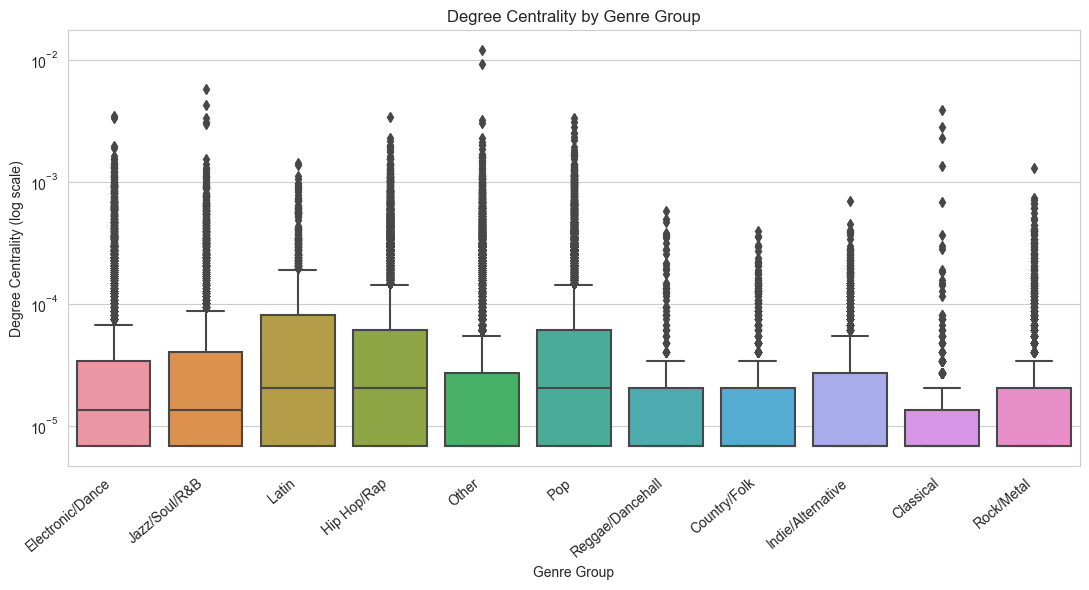

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

order = nodes.groupby("genre_group")["eigenvector_centrality"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=nodes, x="genre_group", y="degree_centrality", order=order, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Genre Group")
ax.set_ylabel("Degree Centrality (log scale)")
ax.set_title("Degree Centrality by Genre Group")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

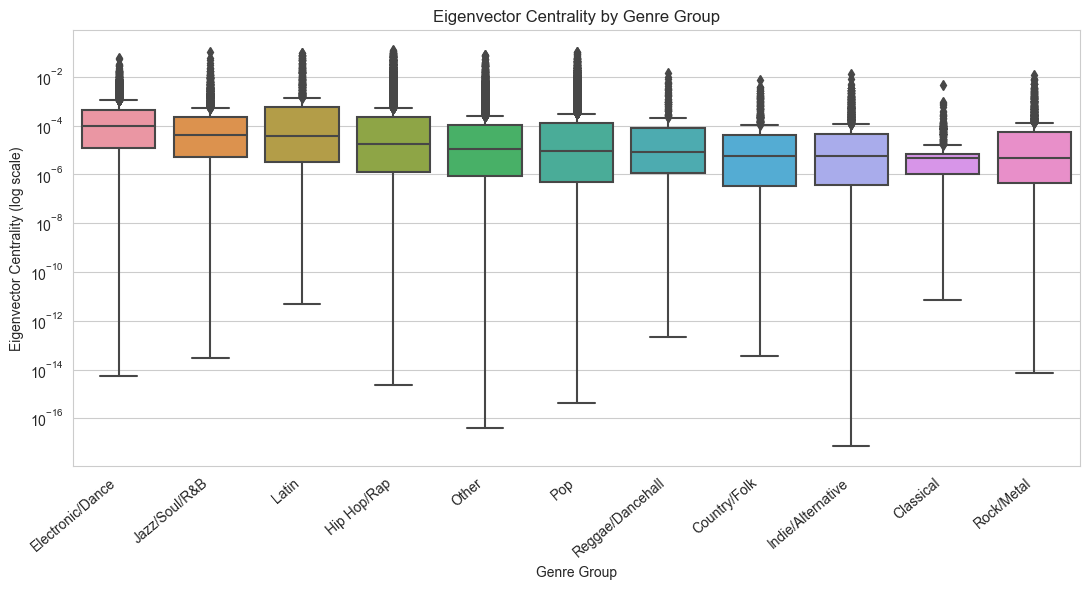

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=nodes, x="genre_group", y="eigenvector_centrality", order=order, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Genre Group")
ax.set_ylabel("Eigenvector Centrality (log scale)")
ax.set_title("Eigenvector Centrality by Genre Group")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

The boxplots show that centrality varies across genre groups, but the differences are more visible on a logarithmic scale because most artists have very low centrality values. Electronic/Dance, Jazz/Soul/R&B, Latin, Hip Hop/Rap, and Pop appear among the more central groups depending on whether we focus on degree centrality or eigenvector centrality. The plots also show many outliers, meaning a small number of highly collaborative artists have much higher centrality than the typical artist in each genre group.

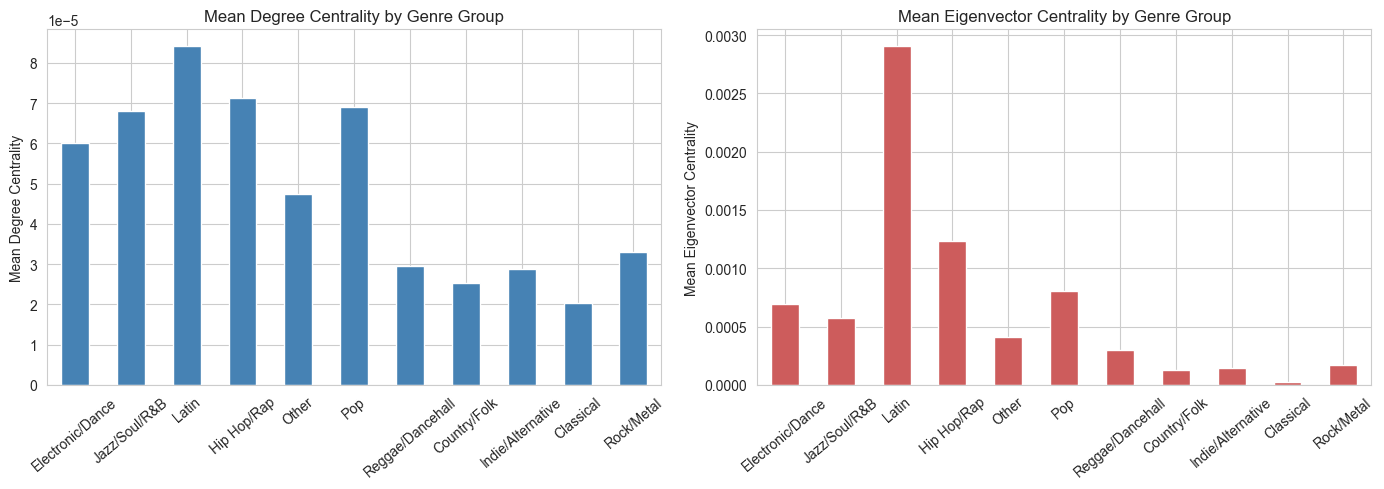

In [13]:
summary_means = nodes.groupby("genre_group")[["degree_centrality", "eigenvector_centrality"]].mean().loc[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_means["degree_centrality"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Mean Degree Centrality by Genre Group")
axes[0].set_ylabel("Mean Degree Centrality")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=40)

summary_means["eigenvector_centrality"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Mean Eigenvector Centrality by Genre Group")
axes[1].set_ylabel("Mean Eigenvector Centrality")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

The mean eigenvector centrality for Latin artists is noticeably higher than for other groups. However, the earlier summary table and boxplots show that this is likely influenced by a small number of extremely central Latin artists rather than representing the typical Latin artist in the network.

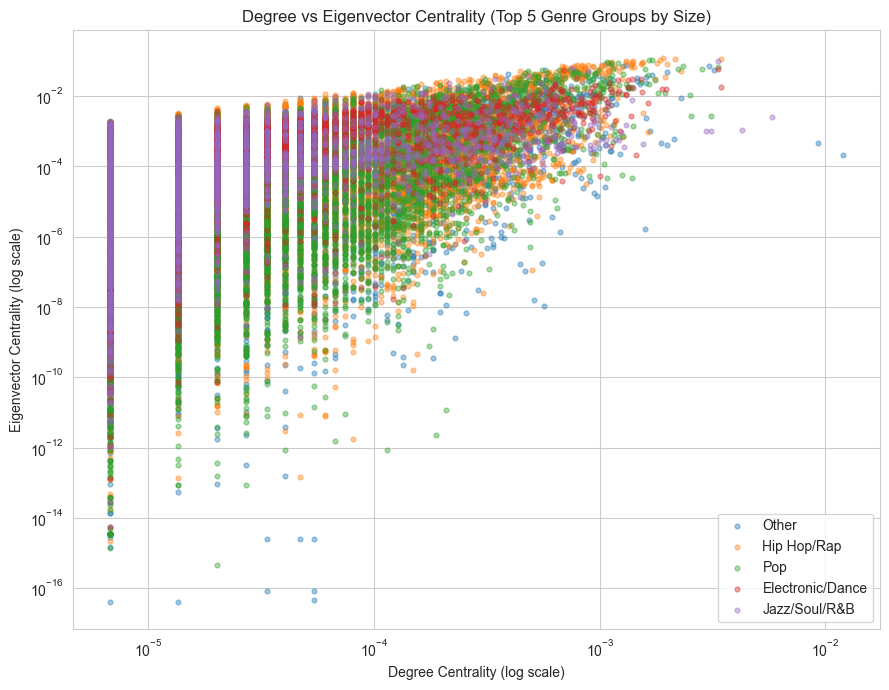

In [14]:
top_groups = nodes["genre_group"].value_counts().head(5).index
subset = nodes[nodes["genre_group"].isin(top_groups)]

fig, ax = plt.subplots(figsize=(9, 7))
for group in top_groups:
    sub = subset[subset["genre_group"] == group]
    ax.scatter(sub["degree_centrality"], sub["eigenvector_centrality"], alpha=0.4, s=12, label=group)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Degree Centrality (log scale)")
ax.set_ylabel("Eigenvector Centrality (log scale)")
ax.set_title("Degree vs Eigenvector Centrality (Top 5 Genre Groups by Size)")
ax.legend()
plt.tight_layout()
plt.show()

The scatter plot shows a clear positive relationship between degree centrality and eigenvector centrality. Artists with more direct collaborations often also have higher eigenvector centrality, especially when those collaborations connect them to other highly central artists. However, some artists with relatively low degree centrality still have higher eigenvector centrality because they are connected to important collaborators.

# 7. Statistical Testing

Now we test whether the differences we are seeing across genre groups are statistically significant, or whether they could just be due to chance.

Since both centrality measures are heavily skewed and clearly not normally distributed, a standard one way ANOVA is not the most appropriate test here. Instead we start with the Kruskal-Wallis test, which is the non-parametric equivalent of an ANOVA and does not assume normally distributed data. It tests whether the centrality distributions differ across all of our genre groups at once.

In [15]:
from scipy import stats

dc_groups = [nodes[nodes["genre_group"] == g]["degree_centrality"] for g in nodes["genre_group"].unique()]
ec_groups = [nodes[nodes["genre_group"] == g]["eigenvector_centrality"] for g in nodes["genre_group"].unique()]

kw_degree = stats.kruskal(*dc_groups)
kw_eigen = stats.kruskal(*ec_groups)

print("Kruskal-Wallis test, degree centrality across genre groups:")
print("  H statistic:", round(kw_degree.statistic, 2), " p-value:", kw_degree.pvalue)
print()
print("Kruskal-Wallis test, eigenvector centrality across genre groups:")
print("  H statistic:", round(kw_eigen.statistic, 2), " p-value:", kw_eigen.pvalue)

Kruskal-Wallis test, degree centrality across genre groups:
  H statistic: 2390.04  p-value: 0.0

Kruskal-Wallis test, eigenvector centrality across genre groups:
  H statistic: 2580.57  p-value: 0.0


In [16]:
n = len(nodes)
k = nodes["genre_group"].nunique()

epsilon_degree = (kw_degree.statistic - k + 1) / (n - k)
epsilon_eigen = (kw_eigen.statistic - k + 1) / (n - k)

print("Effect size for degree centrality, epsilon-squared:", round(epsilon_degree, 4))
print("Effect size for eigenvector centrality, epsilon-squared:", round(epsilon_eigen, 4))

Effect size for degree centrality, epsilon-squared: 0.0463
Effect size for eigenvector centrality, epsilon-squared: 0.05


Both Kruskal-Wallis tests return p-values below 0.05, so we reject the null hypothesis that the centrality distributions are the same across all genre groups. In plain terms, genre group is associated with statistically significant differences in both degree centrality and eigenvector centrality.

The epsilon-squared values give us an estimate of effect size for the Kruskal-Wallis tests. This is useful because very large datasets can produce extremely small p-values even when the practical differences between groups are modest.

Following the example in the assignment, where pairwise comparisons were used to compare specific categories, we now zoom in on the two largest genre groups in our dataset: Hip Hop/Rap and Pop.

In [17]:
hiphop_degree = nodes[nodes["genre_group"] == "Hip Hop/Rap"]["degree_centrality"]
pop_degree = nodes[nodes["genre_group"] == "Pop"]["degree_centrality"]

hiphop_eigen = nodes[nodes["genre_group"] == "Hip Hop/Rap"]["eigenvector_centrality"]
pop_eigen = nodes[nodes["genre_group"] == "Pop"]["eigenvector_centrality"]

t_degree = stats.ttest_ind(hiphop_degree, pop_degree, equal_var=False)
t_eigen = stats.ttest_ind(hiphop_eigen, pop_eigen, equal_var=False)

u_degree = stats.mannwhitneyu(hiphop_degree, pop_degree)
u_eigen = stats.mannwhitneyu(hiphop_eigen, pop_eigen)

print("Hip Hop/Rap vs Pop, degree centrality")
print("  Welch t-test:      t =", round(t_degree.statistic, 3), " p =", round(t_degree.pvalue, 4))
print("  Mann-Whitney U:     p =", round(u_degree.pvalue, 4))
print("  Hip Hop/Rap mean:", hiphop_degree.mean(), " Pop mean:", pop_degree.mean())
print()
print("Hip Hop/Rap vs Pop, eigenvector centrality")
print("  Welch t-test:      t =", round(t_eigen.statistic, 3), " p =", t_eigen.pvalue)
print("  Mann-Whitney U:     p =", u_eigen.pvalue)
print("  Hip Hop/Rap mean:", hiphop_eigen.mean(), " Pop mean:", pop_eigen.mean())

Hip Hop/Rap vs Pop, degree centrality
  Welch t-test:      t = 1.137  p = 0.2555
  Mann-Whitney U:     p = 0.0007
  Hip Hop/Rap mean: 7.14068629980012e-05  Pop mean: 6.907163127813154e-05

Hip Hop/Rap vs Pop, eigenvector centrality
  Welch t-test:      t = 6.011  p = 1.8700334345048506e-09
  Mann-Whitney U:     p = 6.989617992517044e-42
  Hip Hop/Rap mean: 0.0012353750462605307  Pop mean: 0.0008013989656115461


For degree centrality, the Welch t-test does not find a statistically significant difference between Hip Hop/Rap and Pop artists at the 0.05 level. However, the Mann-Whitney U test does show a significant difference. This disagreement is reasonable because the data are highly skewed: the t-test compares means, while the Mann-Whitney test is based on rank differences across the distributions.

For eigenvector centrality, both tests show statistically significant differences. Hip Hop/Rap artists have higher average eigenvector centrality than Pop artists in this dataset, suggesting that they are more likely to connect to other highly central collaborators.

# 8. Most Central Artists

To put real artist names behind the centrality measures, we identify the most central artists by both degree centrality and eigenvector centrality. Degree centrality shows which artists have the most direct collaboration connections, while eigenvector centrality shows which artists are connected to other highly connected artists.

In [18]:
top_degree = nodes.nlargest(5, "degree_centrality")[
    ["name", "genre_group", "primary_genre", "degree_centrality", "eigenvector_centrality"]
]

top_degree

,name,genre_group,primary_genre,degree_centrality,eigenvector_centrality
12406,Johann Sebastian Bach,Other,baroque,0.012003,0.000208
18735,Traditional,Other,puirt-a-beul,0.009239,0.000458
5609,Mc Gw,Jazz/Soul/R&B,funk carioca,0.005782,0.002593
13370,MC MN,Jazz/Soul/R&B,funk carioca,0.004259,0.001064
11577,Jean Sibelius,Classical,classical,0.003909,0.000059


The artists with the highest degree centrality are those with the most direct collaboration connections in the network. These artists are important because they connect directly to many other artists.

In [19]:
nodes.nlargest(5, "eigenvector_centrality")[["name", "genre_group", "primary_genre", "degree_centrality", "eigenvector_centrality"]]

,name,genre_group,primary_genre,degree_centrality,eigenvector_centrality
7897,Farruko,Hip Hop/Rap,latin hip hop,0.001914,0.124674
15578,French Montana,Hip Hop/Rap,gangster rap,0.002157,0.117454
8030,Gucci Mane,Hip Hop/Rap,atl hip hop,0.003430,0.113027
4264,Ty Dolla $ign,Pop,dance pop,0.001698,0.108986
16851,Lil Wayne,Hip Hop/Rap,hip hop,0.001840,0.105402


In [20]:
top_per_group = nodes.loc[nodes.groupby("genre_group")["eigenvector_centrality"].idxmax()]
top_per_group[["genre_group", "name", "primary_genre", "degree_centrality", "eigenvector_centrality"]].sort_values("eigenvector_centrality", ascending=False)

,genre_group,name,primary_genre,degree_centrality,eigenvector_centrality
7897,Hip Hop/Rap,Farruko,latin hip hop,0.001914,0.124674
4264,Pop,Ty Dolla $ign,dance pop,0.001698,0.108986
19434,Jazz/Soul/R&B,Snoop Dogg,g funk,0.003336,0.102871
18411,Latin,J Balvin,reggaeton,0.001382,0.098754
14983,Other,El Alfa,dembow,0.001058,0.079859
7956,Electronic/Dance,Diplo,edm,0.003329,0.059576
7061,Reggae/Dancehall,Damian Marley,reggae,0.000377,0.014346
16782,Indie/Alternative,Kiiara,alt z,0.000398,0.013716
3610,Rock/Metal,Santana,blues rock,0.000714,0.012283
9824,Country/Folk,Tropical Florida,folklore paraguayo,0.000088,0.007663


The most central artists by eigenvector centrality are dominated by Hip Hop/Rap artists, with Farruko, French Montana, Gucci Mane, and Lil Wayne appearing in the top five. This lines up with the statistical results, which showed that Hip Hop/Rap artists have higher eigenvector centrality than Pop artists in this dataset. It is also worth noting that the most central Latin artist, J Balvin, has an eigenvector centrality close to the highest artists in the entire network, which helps explain why the Latin genre group's mean eigenvector centrality was much higher than its median earlier in the notebook.

# 9. Conclusion and Limitations

Our analysis of the Spotify artist collaboration network shows that genre group is associated with how central an artist is within the network. Using Kruskal-Wallis tests, we found statistically significant differences across genre groups for both degree centrality and eigenvector centrality. This means that artists from different genre groups do not occupy the collaboration network in exactly the same way.

The results suggest that Hip Hop/Rap, Latin, Electronic/Dance, Jazz/Soul/R&B, and Pop are among the more central genre groups, depending on whether we focus on direct collaborations or connections to other highly connected artists. When comparing the two largest groups directly, Hip Hop/Rap and Pop, the results showed that they do not differ as clearly in degree centrality, but Hip Hop/Rap artists have significantly higher eigenvector centrality. In practical terms, this suggests that Hip Hop/Rap artists are more likely to collaborate with other highly central artists in the network.

These results make sense in the context of Spotify collaborations because featured artists and guest verses often connect artists across songs, albums, and genre communities. In genres such as Hip Hop/Rap, repeated collaborations with highly connected artists can increase an artist's eigenvector centrality even if the artist does not have the highest number of direct collaborations.

There are also limitations to this analysis. First, each artist was assigned to one genre group using the first listed Spotify genre tag, even though many artists belong to multiple genres. Second, the broad genre categories were created using keyword matching, so some artists may have been placed into categories that do not perfectly reflect their musical style. Third, the “Other” category is large and contains many different micro-genres, so it should be interpreted carefully. Finally, centrality measures describe network position, but they do not prove artistic influence, popularity, or commercial success by themselves.